# Part 1: Data Analysis, Text Cleaning and Baselines

**Project:** Vaccine sentiment analysis with sequential NLP models (Formative Assignment 2)
**Written by:** Adossi Fred William

This notebook is my part of the group project and it has to come first because the Simple RNN, LSTM and GRU notebooks all depend on the decisions made here. Before any of those models can be trained we need to understand what the tweets actually look like, decide how they should be cleaned and agree on one training/validation split since the comparison between the five models is only fair if they all learn from and are tested on the same data. The two baseline models (TF-IDF with Ridge regression and TF-IDF with SVR) will be added at the end of this notebook once the data work is finished so that they can also use the same cleaning and the same split.

Rather than making charts for their own sake I tried to let each analysis answer a question that matters for the project. For that reason every table or figure is followed by an explanation of what I noticed and how it changes the way we clean the text, split the data or evaluate the models so the notebook can be read as one line of reasoning from the raw file to the final decisions.

To run the notebook open it from the repository on your own computer or in Google Colab and run all the cells. `Train.csv` needs to be in the main folder of the repository and if it is missing in Colab the notebook asks you to upload it. When it finishes it saves the split files (`splits/train_ids.csv` and `splits/validation_ids.csv`) and the figures in `results/figures/`, which are the files the rest of the group will use.

**Publication note:** Saved tweet samples are omitted and quoted examples are paraphrased. Run the sample cells locally with `Train.csv` to inspect the original text. Remove sample text from saved outputs again before publishing a rerun.


## 0. Setting Up the Notebook

The notebook has to find the shared code in `src/` and it needs to do this both on a normal computer and in Colab, where the repository first has to be cloned. The first cell handles this by moving to the main project folder and once that is done the second cell can import the libraries and the shared functions and set one consistent style for all the figures.

In [1]:
# This cell lets the notebook run both locally and on Google Colab, where the repository is cloned first.
import os, subprocess, sys
from pathlib import Path

REPO_URL = "https://github.com/Adossi-design/vaccine-sentiment-sequential-models.git"
if "google.colab" in sys.modules and not Path("src").exists():
    if not Path("vaccine-sentiment-sequential-models").exists():
        subprocess.run(["git", "clone", "-q", REPO_URL], check=True)
    os.chdir("vaccine-sentiment-sequential-models")
elif Path.cwd().name == "notebooks":
    os.chdir("..")  # The notebook always works from the main project folder.
sys.path.insert(0, str(Path.cwd()))
print("Working directory:", Path.cwd())

Working directory: C:\Users\USER\vaccine-sentiment-sequential-models


In [2]:
import collections
import re
import unicodedata

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.config import AGREEMENT_COL, FIGURES_DIR, ID_COL, SEED, TARGET_COL, TEXT_COL
from src.data import (duplicate_group_key, ensure_train_csv, load_split, load_train,
                      make_split, save_split)
from src.evaluate import mae, rmse
from src.preprocess import DEFAULT_CONFIG, EMOJI_RE, TextConfig, prepare_series, tokenize

np.random.seed(SEED)
pd.set_option("display.max_colwidth", 150)
pd.set_option("display.width", 200)

# The chart colours are red for negative, gray for neutral and blue for positive and they were checked for colour-blind readers.
LABEL_COLORS = {-1.0: "#e34948", 0.0: "#898781", 1.0: "#2a78d6"}
LABEL_NAMES = {-1.0: "Negative (-1)", 0.0: "Neutral (0)", 1.0: "Positive (+1)"}
AGREEMENT_COLORS = ["#86b6ef", "#2a78d6", "#104281"]  # The shades run from light for 1/3 agreement to dark for full agreement.
SERIES, INK, INK_2, MUTED, GRID, SURFACE = "#2a78d6", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#fcfcfb"
mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.size": 10, "text.color": INK, "axes.labelcolor": INK_2, "axes.titlesize": 11,
    "axes.titleweight": "bold", "axes.titlelocation": "left", "axes.edgecolor": "#c3c2b7",
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelcolor": INK_2, "ytick.labelcolor": INK_2,
    "legend.frameon": False, "lines.linewidth": 2, "savefig.dpi": 200, "savefig.bbox": "tight",
})
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def save_fig(fig, name):
    """Save a figure as a PNG file in results/figures."""
    path = FIGURES_DIR / f"{name}.png"
    fig.savefig(path)
    print("saved", path.relative_to(Path.cwd()))


def contains(texts, pattern, flags=0):
    """Return a True/False Series showing which tweets match the regex pattern."""
    # Python's re is used because newer pandas string methods reject back-references such as \1.
    regex = re.compile(pattern, flags)
    return texts.map(lambda text: bool(regex.search(text)))

## 1. Understanding the Dataset

I start by loading `Train.csv` exactly as it is without fixing anything because any problem in the raw file needs to be found now before it can quietly affect the rest of the analysis.

In [3]:
raw = pd.read_csv(ensure_train_csv(), dtype={ID_COL: str, TEXT_COL: str})
print("shape:", raw.shape)
display(raw.dtypes.to_frame("dtype"))
display(raw.head())

shape: (10001, 4)


,dtype
tweet_id,str
safe_text,str
label,float64
agreement,float64


The file has four columns: `tweet_id`, `safe_text` (the tweet itself), `label` (the sentiment score we want to predict) and `agreement`. In the text usernames and links have already been replaced with `<user>` and `<url>` by the people who made the dataset, which is probably why the column is called "safe" text and also means that we do not need to anonymise anything ourselves. pandas reads 10,001 rows so the next thing to check is whether all of these rows are actually complete.

### Checking Missing Values

In [4]:
display(raw.isna().sum().to_frame("missing values"))
display(raw[raw.isna().any(axis=1)])
print("label values:", sorted(raw[TARGET_COL].dropna().unique()))

,missing values
tweet_id,0
safe_text,0
label,1
agreement,2


label values: [np.float64(-1.0), np.float64(0.0), np.float64(0.6666666666666666), np.float64(1.0)]


Only three values are missing but they are all in two neighbouring rows (4798 and 4799), which already suggests that the problem comes from one place rather than from gaps spread across the file. The list of label values points in the same direction because it contains 0.667 even though the labels should only be -1, 0 and 1. Since both problems appear around the same rows the most sensible next step was to look at the raw lines of the CSV file itself.

In [5]:
# Print the raw lines of the file around the record with missing values.
lines = ensure_train_csv().read_text(encoding="utf-8").split("\n")
broken_line = next(i for i, line in enumerate(lines) if line.startswith("RQMQ0L2A"))
for line in lines[broken_line - 1:broken_line + 3]:
    print(repr(line))

Looking at the raw lines explains both problems at once: the tweet `RQMQ0L2A` had a line break inside its text that was not put in quotes so the file continued the tweet on a new line. On that second line every value moved one column to the left, which means the rest of the text ended up in the `tweet_id` column, the label (`1`) in the `safe_text` column and the agreement (`0.667`) in the `label` column. The strange 0.667 "label" is therefore not a real label at all but the agreement value of this one tweet.

### Fixing the Broken Record

The starter notebook simply drops rows with missing values, which would throw away both lines and lose a labelled tweet. Because all the information is still there and it is clear which value belongs in which column, I decided to join the two lines back into one record instead and I put this repair inside `load_train()` in `src/data.py` so that every notebook in the project loads the data in the same fixed state.

In [6]:
df = load_train()
display(df[df[ID_COL] == "RQMQ0L2A"])
print("missing values after repair:", int(df.isna().sum().sum()))
print("label values after repair:", sorted(df[TARGET_COL].unique()))
print("duplicated tweet_id:", int(df[ID_COL].duplicated().sum()), "| fully duplicated rows:", int(df.duplicated().sum()))

Read 10,001 rows -> 10,000 records after repairing ['RQMQ0L2A']


missing values after repair: 0
label values after repair: [np.float64(-1.0), np.float64(0.0), np.float64(1.0)]
duplicated tweet_id: 0 | fully duplicated rows: 0


After the repair there are 10,000 tweets with no missing values, the labels contain only -1, 0 and 1, and no tweet ID appears twice. Since only one tweet out of 10,000 was affected, the fix will not change any results by itself but it does mean that the whole group starts from the same clean file instead of each person handling the broken rows in a different way.

## 2. Looking at the Sentiment Labels

The label is what all five models will try to predict so the way it is distributed shapes both how the models learn and how their errors should be read later. For this reason I looked at how the three values are spread out and, because every label was given by people, at how much those people agreed with each other.

In [7]:
counts = df[TARGET_COL].value_counts().sort_index()
label_table = pd.DataFrame({"tweets": counts, "share": (counts / len(df)).round(3)})
display(label_table)
print(f"mean label = {df[TARGET_COL].mean():.4f}, standard deviation = {df[TARGET_COL].std(ddof=0):.4f}")
agree = df[AGREEMENT_COL].round(2)
display(pd.crosstab(df[TARGET_COL], agree, margins=True))
display(df.groupby(agree)[TARGET_COL].agg(["count", "mean"]).round(3))

,tweets,share
label,,
-1.0,1038,0.104
0.0,4908,0.491
1.0,4054,0.405


mean label = 0.3016, standard deviation = 0.6467


agreement,0.33,0.67,1.0,All
label,,,,
-1.0,239,417,382,1038
0.0,0,1748,3160,4908
1.0,0,1730,2324,4054
All,239,3895,5866,10000


,count,mean
agreement,,
0.33,239,-1.000
0.67,3895,0.337
1.00,5866,0.331


Almost half of the tweets are neutral (49.1%) and 40.5% are positive, which here means pro-vaccine, while only 10.4% are negative (anti-vaccine). This means that the anti-vaccine tweets, which are probably the most interesting ones from a public health point of view, are also the ones the models will see least often during training. The average label is 0.30, which is above zero because there are many more positive tweets than negative ones.

The `agreement` column only takes the values 1/3, 2/3 and 1, which fits with each tweet being labelled by three people. When I looked at it next to the labels one pattern stood out that I did not expect: all 239 tweets with 1/3 agreement are labelled -1 while none of the neutral or positive tweets have agreement this low. This suggests that the negative labels are not only rarer than the others but also less certain, which the chart below makes easier to see.

saved results\figures\eda_label_distribution.png


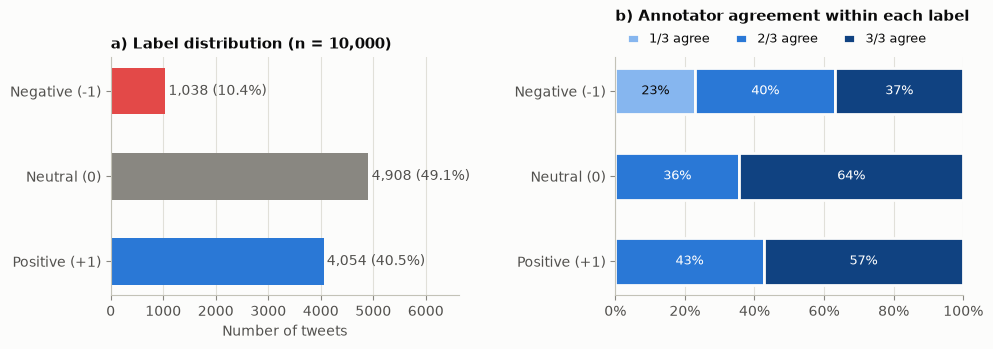

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.1), gridspec_kw={"wspace": 0.45})
labels = [-1.0, 0.0, 1.0]
ypos = np.arange(len(labels))
ax1.barh(ypos, [counts[label] for label in labels], height=0.55, color=[LABEL_COLORS[label] for label in labels])
for y, label in zip(ypos, labels):
    ax1.text(counts[label] + 60, y, f"{counts[label]:,} ({counts[label] / len(df):.1%})", va="center", color=INK_2)
ax1.set_yticks(ypos, [LABEL_NAMES[label] for label in labels])
ax1.invert_yaxis()
ax1.set_xlim(0, counts.max() * 1.35)
ax1.grid(axis="y", visible=False)
ax1.set_xlabel("Number of tweets")
ax1.set_title("a) Label distribution (n = 10,000)")

shares = pd.crosstab(df[TARGET_COL], agree, normalize="index").reindex(labels)
left = np.zeros(len(labels))
for col, colour, name in zip(shares.columns, AGREEMENT_COLORS, ["1/3 agree", "2/3 agree", "3/3 agree"]):
    vals = shares[col].values
    ax2.barh(ypos, vals, left=left, height=0.55, color=colour, edgecolor=SURFACE, linewidth=2, label=name)
    for y, share, start in zip(ypos, vals, left):
        if share >= 0.12:  # Only segments that are wide enough for the text receive a percentage label.
            ax2.text(start + share / 2, y, f"{share:.0%}", ha="center", va="center",
                     color=INK if colour == AGREEMENT_COLORS[0] else "white", fontsize=9)
    left += vals
ax2.set_yticks(ypos, [LABEL_NAMES[label] for label in labels])
ax2.invert_yaxis()
ax2.set_xlim(0, 1)
ax2.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0))
ax2.grid(axis="y", visible=False)
ax2.set_title("b) Annotator agreement within each label", pad=26)
ax2.legend(ncol=3, loc="lower left", bbox_to_anchor=(0, 1.0), handlelength=1, fontsize=9)
save_fig(fig, "eda_label_distribution")
plt.show()

The left chart shows how much shorter the negative bar is than the other two and the right chart shows that this small class also has the weakest labels, since 23% of the negative labels come from tweets where the three annotators did not reach a majority while every neutral and positive label has at least 2/3 agreement. Putting these two facts together the smallest class is also the least reliable one and this has two consequences for the models. Because we treat the task as regression and score it with RMSE, a model trained on this data will be pulled towards the average label of about 0.3 so I expect its biggest mistakes to happen on negative tweets. At the same time some of those mistakes may not really be the model's fault because the label itself may be doubtful, so before deciding what to do with these tweets I wanted to read some of them.

In [9]:
low = df[agree == 0.33]
print(f"{len(low)} tweets have agreement 1/3; their labels: {low[TARGET_COL].value_counts().to_dict()}")
display(low.sample(12, random_state=SEED)[[TEXT_COL, TARGET_COL]])

239 tweets have agreement 1/3; their labels: {-1.0: 239}


The sample contains both clear opposition to vaccination and material that reads more like neutral reporting about vaccine development or exemptions. Because many of them are real negative examples, removing all the low-agreement tweets would also remove useful data from a class that is already small so I kept them and will come back to them in the error analysis to see whether they account for a large share of the errors.

The way the labels were made also decides how `agreement` can be used. It comes from the annotators, which means a new tweet would never have an agreement value so using it as a model input would give the models information they could not have in practice. I therefore only use it to balance the split in section 9 and later to help explain the errors.

## 3. Duplicate Tweets

On Twitter the same text is often retweeted or shared with the same news headline so I expected some tweets to appear more than once. Exact copies are easy to find but copies of a retweet often differ only in a mention, a link or some punctuation so I also grouped near-duplicates, meaning tweets that become identical after lowercasing and removing `<user>`, `<url>`, "RT" and punctuation.

In [10]:
print("tweets whose exact text appears earlier in the file:", int(df[TEXT_COL].duplicated().sum()))
groups = df[TEXT_COL].map(duplicate_group_key)
group_size = groups.map(groups.value_counts())
group_stats = df.groupby(groups)[TARGET_COL].agg(copies="size", distinct_labels="nunique", mean_label="mean")
repeated_groups = group_stats[group_stats["copies"] > 1]
print(f"near-duplicate groups (same normalised text): {len(repeated_groups)} groups covering {int((group_size > 1).sum())} tweets")
print(f"groups whose copies carry different labels: {int((repeated_groups['distinct_labels'] > 1).sum())}")
in_dup = group_size > 1
noise_rmse = rmse(df.loc[in_dup, TARGET_COL], groups[in_dup].map(group_stats["mean_label"]))
print(f"RMSE of predicting each duplicated tweet by its own group's mean label: {noise_rmse:.4f}")
top = repeated_groups.sort_values("copies", ascending=False).head(8).copy()
top["label_counts"] = [df.loc[groups == key, TARGET_COL].value_counts().to_dict() for key in top.index]
display(top[["copies", "label_counts"]])

tweets whose exact text appears earlier in the file: 343
near-duplicate groups (same normalised text): 188 groups covering 655 tweets
groups whose copies carry different labels: 43
RMSE of predicting each duplicated tweet by its own group's mean label: 0.2435


There are 343 exact repeats and with the looser grouping 188 groups cover 655 tweets, which is about 6.6% of the data, with the biggest group containing 59 copies of a single tweet about complaining and immunity. More important than the number of copies is that in 43 of these groups the copies do not all have the same label. For example, a repeated news headline about research on MMR and autism is labelled positive 15 times and neutral twice even though the text is identical. Because of this disagreement even a model that predicted the average label of each group would still have an RMSE of about 0.24 on these tweets, which shows that part of the error in this task comes from the annotators rather than from the models and no model can remove that part.

The duplicates also change how the data has to be split. With a random split copies of the same tweet could end up in both the training and the validation set and the models would then be rewarded for remembering tweets they had already seen instead of for learning patterns that work on new ones. This is a form of data leakage that would make the validation scores look better than they really are so although I kept all the copies because they are real data, each group has to stay together on one side of the split, which is how the split in section 9 is built.

## 4. Tweet Length Analysis

Sequence length matters directly for this project because the RNN, LSTM and GRU read a tweet one token at a time and every tweet has to be padded or cut to the same length before training. To choose that length sensibly I measured tweet length in characters, in words and in tokens after the cleaning described in section 8 since the token count is what the neural models will actually see.

In [11]:
lengths = pd.DataFrame({
    "characters": df[TEXT_COL].str.len(),
    "words (whitespace)": df[TEXT_COL].str.split().str.len(),
    "tokens (after preprocessing)": df[TEXT_COL].map(lambda text: len(tokenize(text))),
})
display(lengths.describe(percentiles=[0.05, 0.5, 0.9, 0.95, 0.99, 0.999]).round(1))
print("tweets longer than 140 characters:", int((lengths["characters"] > 140).sum()))
short = lengths["words (whitespace)"] <= 3
print("tweets with <= 3 words:", int(short.sum()), "| their labels:", df.loc[short, TARGET_COL].value_counts().to_dict())
display(lengths.groupby(df[TARGET_COL]).median())

,characters,words (whitespace),tokens (after preprocessing)
count,10000.0,10000.0,10000.0
mean,99.9,16.3,16.8
std,29.9,5.3,5.5
min,3.0,1.0,1.0
5%,42.0,7.0,7.0
50%,107.0,17.0,17.0
90%,134.0,23.0,24.0
95%,138.0,24.0,25.0
99%,140.0,27.0,28.0
99.9%,147.0,31.0,32.0


tweets longer than 140 characters: 99
tweets with <= 3 words: 68 | their labels: {0.0: 53, 1.0: 9, -1.0: 6}


,characters,words (whitespace),tokens (after preprocessing)
label,,,
-1.0,109.0,17.0,18.0
0.0,104.0,16.0,17.0
1.0,111.0,18.0,18.0


The tweets are short with a median of 17 tokens, and since 95% of them have 25 tokens or fewer and 99.9% have 32 or fewer, only a handful come close to the longest tweet at 48 tokens. The character count reaches 153, which is above Twitter's old limit of 140, and this is probably because HTML codes like `&amp;` use five characters to show a single symbol (there are examples of this in section 5). At the other end, 68 tweets have three words or fewer and 53 of them are neutral, which makes sense because a tweet that short rarely has room to express an opinion. The median length is also almost the same for the three labels (17 or 18 tokens), which already suggests that length on its own will not tell the models much about sentiment.

saved results\figures\eda_sequence_length.png


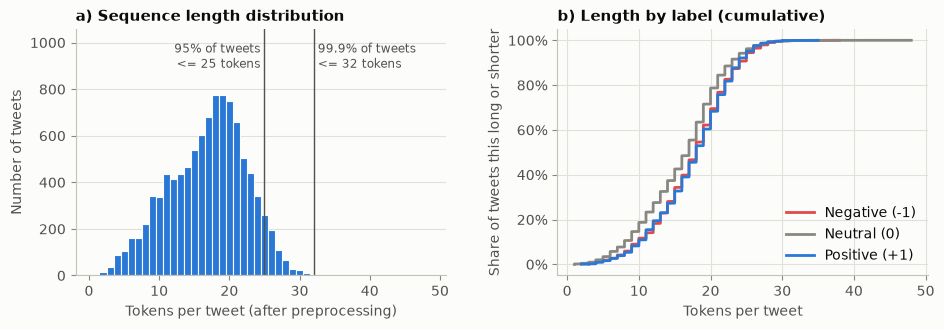

In [12]:
tok_len = lengths["tokens (after preprocessing)"]
p95, p999 = np.percentile(tok_len, [95, 99.9])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.2), gridspec_kw={"wspace": 0.3})
ax1.hist(tok_len, bins=np.arange(0.5, tok_len.max() + 1.5, 1), color=SERIES, edgecolor=SURFACE, linewidth=0.8)
ax1.set_ylim(0, ax1.get_ylim()[1] * 1.3)  # Extra space above the bars keeps the percentile labels clear of the data.
top_y = ax1.get_ylim()[1]
ax1.axvline(p95, color=INK_2, linewidth=1)
ax1.text(p95 - 0.6, top_y * 0.95, f"95% of tweets\n<= {p95:.0f} tokens", color=INK_2, fontsize=8.5, va="top", ha="right")
ax1.axvline(p999, color=INK_2, linewidth=1)
ax1.text(p999 + 0.6, top_y * 0.95, f"99.9% of tweets\n<= {p999:.0f} tokens", color=INK_2, fontsize=8.5, va="top")
ax1.set_xlabel("Tokens per tweet (after preprocessing)")
ax1.set_ylabel("Number of tweets")
ax1.grid(axis="x", visible=False)
ax1.set_title("a) Sequence length distribution")
for label in labels:
    sorted_lengths = np.sort(tok_len[df[TARGET_COL] == label].values)
    ax2.plot(sorted_lengths, np.arange(1, len(sorted_lengths) + 1) / len(sorted_lengths),
             color=LABEL_COLORS[label], label=LABEL_NAMES[label])
ax2.set_xlabel("Tokens per tweet")
ax2.set_ylabel("Share of tweets this long or shorter")
ax2.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0))
ax2.legend(loc="lower right")
ax2.set_title("b) Length by label (cumulative)")
save_fig(fig, "eda_sequence_length")
plt.show()

The figure confirms this picture since the histogram shows that most tweets have between about 10 and 25 tokens with the peak at 18 to 19 and that very few go above 30, so a fixed length a little above 30 would cover almost every tweet without adding much padding. In the cumulative chart on the right the three lines lie close together, and although the neutral line sits slightly to the left because neutral tweets are a little shorter, the gap is too small for length to be a useful signal of sentiment.

In [13]:
display(df.loc[short, [TEXT_COL, TARGET_COL, AGREEMENT_COL]].sample(10, random_state=SEED))
display(df.loc[tok_len.nlargest(3).index, [TEXT_COL, TARGET_COL]])

The examples show what the two ends of the distribution look like. The very short tweets containing only a mention, an ambiguous abbreviation or an emoji give almost no information so any model will struggle with them no matter how it is built, while the three longest tweets are long mainly because every "!" and every emoji counts as a separate token rather than because they contain longer arguments.

For the sequential models these short sequences mean that padding every tweet to the same length is cheap but they also raise a question that our experiments should answer. LSTM and GRU were designed to remember information over long sequences and since our tweets only have around 17 to 32 steps, it is possible that their gates will not help much compared with a Simple RNN on this dataset. The exact sequence length is chosen in section 10 using only the training data so that this decision does not depend on the validation tweets.

## 5. Mentions, Links, Hashtags and Emojis

Tweets contain elements that normal text does not, such as mentions, links, hashtags and emojis together with noise like HTML codes and stretched words. A common approach is to remove most of these during cleaning but if a feature appears more often in one label than in the others, removing it would throw away information that the models could use. Before deciding what to keep I therefore counted how often each feature appears overall and within each label.

In [14]:
NEGATION = r"\b(not|no|never|nobody|nothing|nor|none)\b|n['’]t\b"
features = {
    "<user> mention": (r"<user>", 0),
    "<url> link": (r"<url>", 0),
    "Hashtag": (r"#\w+", 0),
    "Negation word": (NEGATION, re.I),
    "ALL-CAPS word (3+ letters)": (r"\b[A-Z]{3,}\b", 0),
    "Exclamation mark": (r"!", 0),
    "Question mark": (r"\?", 0),
    "Ellipsis (…)": ("…", 0),
    "HTML entity (&amp; etc.)": (r"&(amp|lt|gt|quot);", 0),
    "Emoji": (EMOJI_RE.pattern, 0),
    "Line break": (r"\n", 0),
    "Elongated word (sooo)": (r"([^\W\d_])\1{2,}", 0),
}
presence = pd.DataFrame({name: contains(df[TEXT_COL], pattern, flags) for name, (pattern, flags) in features.items()})
feature_table = pd.concat([presence.mean().rename("all tweets"),
                           presence.groupby(df[TARGET_COL]).mean().T.rename(columns=LABEL_NAMES)], axis=1)
display((feature_table * 100).round(1).rename(columns=lambda c: f"% {c}"))

,% all tweets,% Negative (-1),% Neutral (0),% Positive (+1)
<user> mention,40.4,54.3,38.2,39.5
<url> link,43.7,39.6,48.6,38.9
Hashtag,26.6,28.0,26.1,26.9
Negation word,25.9,34.6,17.1,34.4
ALL-CAPS word (3+ letters),24.5,25.7,27.4,20.7
Exclamation mark,13.3,12.9,10.9,16.5
Question mark,12.4,17.6,11.5,12.0
Ellipsis (…),8.5,2.5,12.9,4.7
HTML entity (&amp; etc.),5.9,8.1,5.1,6.4
Emoji,5.1,2.5,6.5,4.0


Mentions and links are very common with `<user>` in 40% of tweets and `<url>` in 44%, but for modelling the differences between the labels matter more than these totals. `<user>` appears in 54% of negative tweets compared with about 38 to 40% of the others, which might mean that anti-vaccine tweets are more often replies or arguments with other users, whereas `<url>` is most common in neutral tweets (49%), which fits with many of them being shared news. The same kind of difference appears in the punctuation since the "…" symbol is in 12.9% of neutral tweets but only 2.5% of negative ones, question marks are more common in negative tweets (17.6%) and exclamation marks are more common in positive tweets (16.5%). Because each of these features leans towards a particular label, removing them during cleaning would take away small but real clues about sentiment.

The noise features are much less common with HTML codes in 5.9% of tweets, line breaks in 4.4% and words with stretched spellings in only 1.2% so they mainly need to be cleaned so that the same word is not split into several different tokens. ALL-CAPS words on the other hand appear in almost a quarter of the tweets but many of them are simply abbreviations like MMR or CDC, which means that capital letters are not a reliable sign of emotion in this dataset and keeping them would mostly make the vocabulary larger.

saved results\figures\eda_text_features_by_label.png


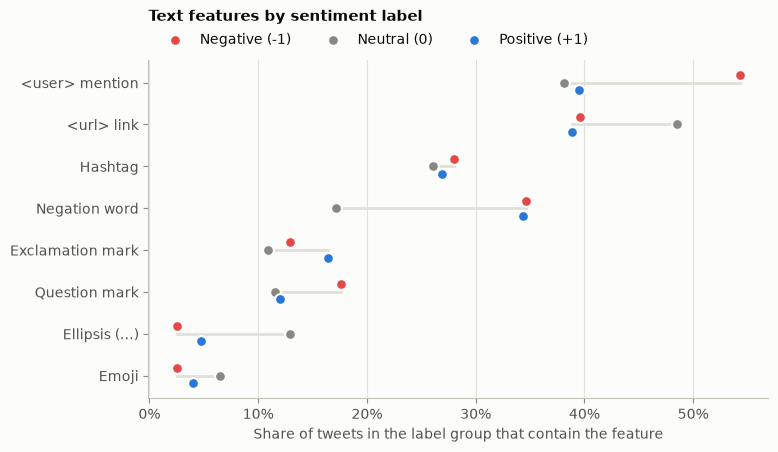

In [15]:
plot_feats = ["<user> mention", "<url> link", "Hashtag", "Negation word", "Exclamation mark",
              "Question mark", "Ellipsis (…)", "Emoji"]
fig, ax = plt.subplots(figsize=(8, 4.4))
y_positions = np.arange(len(plot_feats))
by_label = presence.groupby(df[TARGET_COL]).mean()
offsets = {-1.0: -0.18, 0.0: 0.0, 1.0: 0.18}  # A small vertical offset prevents dots with equal values from hiding each other.
for y, feature in zip(y_positions, plot_feats):
    feature_shares = by_label[feature].values
    ax.plot([feature_shares.min(), feature_shares.max()], [y, y], color=GRID, linewidth=2, zorder=1)
for label in labels:
    ax.scatter(by_label.loc[label, plot_feats], y_positions + offsets[label], s=60, color=LABEL_COLORS[label],
               edgecolor=SURFACE, linewidth=1.5, zorder=2, label=LABEL_NAMES[label])
ax.set_yticks(y_positions, plot_feats)
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0))
ax.set_xlabel("Share of tweets in the label group that contain the feature")
ax.grid(axis="y", visible=False)
ax.legend(ncol=3, loc="lower left", bbox_to_anchor=(0, 1.0))
ax.set_title("Text features by sentiment label", pad=28)
save_fig(fig, "eda_text_features_by_label")
plt.show()

The chart shows the same differences in a way that is easier to compare. When the three dots of a feature are far apart, as they are for mentions, links, negation words and "…", the feature seems to be connected to the label, whereas the three dots for hashtags are almost on top of each other, which means that simply having a hashtag says very little about sentiment. This does not make hashtags useless though because the information may be in which hashtag is used rather than in whether there is one, so the next step was to look at the most common hashtags and emojis individually.

In [16]:
all_tokens = collections.Counter(token for tweet in df[TEXT_COL] for token in tokenize(tweet))
emoji_counts = collections.Counter({token: count for token, count in all_tokens.items() if EMOJI_RE.fullmatch(token)})
print("most frequent emojis:", emoji_counts.most_common(12))
hashtags = collections.Counter({token: count for token, count in all_tokens.items() if token.startswith("#")})
print(f"{len(hashtags)} distinct hashtags; most frequent:", hashtags.most_common(20))
for name in ["HTML entity (&amp; etc.)", "Line break", "Elongated word (sooo)"]:
    print(f"\n{name} - examples:")
    for tweet in df.loc[presence[name], TEXT_COL].head(3):
        print("   ", repr(tweet))

most frequent emojis: [('😂', 140), ('💉', 63), ('😷', 58), ('🔥', 52), ('😭', 40), ('😳', 39), ('💥', 30), ('😒', 29), ('🙌', 27), ('👏', 25), ('😡', 25), ('😩', 23)]
2295 distinct hashtags; most frequent: [('#mmr', 373), ('#measles', 341), ('#vaccineswork', 146), ('#vaccines', 122), ('#vaccine', 98), ('#ebola', 83), ('#cdcwhistleblower', 74), ('#autism', 73), ('#vaccinate', 71), ('#health', 57), ('#vaccinations', 54), ('#dc', 49), ('#vaccinateyourkids', 47), ('#dj', 47), ('#gop', 44), ('#measlesoutbreak', 39), ('#immigrants', 39), ('#ainf', 39), ('#mixmasterrod', 37), ('#vaccination', 30)]


In [17]:
# This table shows how the tweets containing some of the most common hashtags are labelled.
rows = []
for tag in ["#vaccineswork", "#vaccinateyourkids", "#cdcwhistleblower", "#vaccines", "#mmr"]:
    has_tag = contains(df[TEXT_COL], re.escape(tag) + r"\b", re.I)
    tag_labels = df.loc[has_tag, TARGET_COL]
    rows.append({"hashtag": tag, "tweets": int(has_tag.sum()),
                 "% negative": 100 * (tag_labels == -1).mean(),
                 "% neutral": 100 * (tag_labels == 0).mean(),
                 "% positive": 100 * (tag_labels == 1).mean()})
display(pd.DataFrame(rows).round(1).set_index("hashtag"))

,tweets,% negative,% neutral,% positive
hashtag,,,,
#vaccineswork,146,4.8,8.9,86.3
#vaccinateyourkids,46,0.0,2.2,97.8
#cdcwhistleblower,74,90.5,5.4,4.1
#vaccines,121,25.6,20.7,53.7
#mmr,372,1.1,95.4,3.5


The most common emojis are 😂, 💉, 😷, 🔥 and 😭 and they seem to be used in two different ways: some express a feeling (😂, 😭, 😡) while others such as 💉 and 😷 mostly refer to the topic itself. Emojis appear in only 5.1% of tweets but I still decided to keep them as tokens because in texts this short they are one of the few direct ways people show emotion.

The hashtag table gives a much stronger reason for keeping hashtags. Out of 2,295 different hashtags some are almost a label on their own: tweets with #vaccinateyourkids are 97.8% positive and tweets with #vaccineswork are 86.3% positive while 90.5% of the tweets with #cdcwhistleblower are negative. Other hashtags behave differently since #mmr is 95.4% neutral and #vaccines is mixed, and this is exactly why hashtags looked uninformative in the chart above when they were only counted as present or absent. Deleting hashtags would therefore remove some of the strongest clues in the dataset so they are kept as tokens. The printed examples also show that HTML codes like `&amp;` should be turned back into normal symbols and that line breaks can safely be treated as spaces, which is how the cleaning in section 8 handles them.

In [18]:
# This check looks for tweets written in other scripts or mixing languages (code-switching).
non_latin = df[TEXT_COL].map(
    lambda text: any(char.isalpha() and not unicodedata.name(char, "").startswith("LATIN") for char in text))
accented = df[TEXT_COL].map(
    lambda text: any(char.isalpha() and ord(char) > 127 and unicodedata.name(char, "").startswith("LATIN") for char in text))
print("tweets containing non-Latin letters:", int(non_latin.sum()))
print("tweets containing accented Latin letters:", int(accented.sum()))
display(df.loc[non_latin | accented, [TEXT_COL, TARGET_COL]].head(8))

tweets containing non-Latin letters: 6
tweets containing accented Latin letters: 18


The assignment mentions code-switching so I also checked whether any tweets are written in other languages. Only 6 tweets contain non-Latin letters and 18 contain accented Latin letters and the ones shown above include a few tweets in Spanish, one in Turkish and one in Japanese along with English tweets containing an accented brand name. The dataset is therefore essentially English and with so few tweets in other languages there is no real benefit in treating them separately, so no language-specific processing is needed.

## 6. Negation and Word Order

Negation deserved its own check because it is one of the main reasons for trying sequential models on this problem. A word like "not" or "don't" can flip the meaning of a sentence but only in combination with the words around it, so a model can only interpret it correctly if it pays attention to word order.

In [19]:
neg = presence["Negation word"]
contrast = contains(df[TEXT_COL], r"\b(but|however|although|though|yet)\b", re.I)
display(pd.DataFrame({"% with negation": neg.groupby(df[TARGET_COL]).mean() * 100,
                      "% with contrast word": contrast.groupby(df[TARGET_COL]).mean() * 100}).round(1).rename(index=LABEL_NAMES))
examples = pd.concat([df[neg & (df[TARGET_COL] == label)].sample(4, random_state=SEED) for label in [1.0, -1.0]])
display(examples[[TEXT_COL, TARGET_COL]])

,% with negation,% with contrast word
label,,
Negative (-1),34.6,6.5
Neutral (0),17.1,4.3
Positive (+1),34.4,7.2


Negation words appear in 34.6% of negative tweets and 34.4% of positive tweets but only in 17.1% of neutral ones, which means that negation tells us a tweet expresses an opinion but not which side of the debate it is on. Inspection of the local examples showed both criticism of parents who refuse vaccination and statements refusing vaccination. These opposing views use overlapping vocabulary, so the surrounding sentence and its structure matter. Contrast words are much rarer, appearing in only about 4 to 7% of tweets, so they are less likely to have a large effect on the results.

The sample also contains a questionable label: a tweet about an insurance message and the preventability of measles appears to support vaccination but is labelled negative. This adds to the evidence from sections 2 and 3 that the labels contain some noise.

This connects directly to our choice of models because a unigram TF-IDF model represents individual words without their order, although word pairs can capture some local context. The recurrent models read the tweet from beginning to end, so in theory they can track longer sentence structures. Whether this advantage actually shows up on our data is one of the main things the experiments need to test.

## 7. Topic Words and Ambiguous Words

Because every tweet in this dataset is about vaccines or diseases, some words appear very often simply because of the topic. If one of these topic words is strongly linked to a single label, a model might learn to rely on it instead of reading the whole tweet so I checked how the most common topic words relate to the labels.

In [20]:
rows = []
for keyword in ["measles", "mmr", "autism", "flu", "ebola", "hpv", "disney", "whooping", "immun"]:
    has_keyword = contains(df[TEXT_COL], keyword, re.I)
    rows.append({"keyword": keyword, "% of tweets": 100 * has_keyword.mean(),
                 "mean label": df.loc[has_keyword, TARGET_COL].mean(),
                 "% negative (-1)": 100 * (df.loc[has_keyword, TARGET_COL] == -1).mean()})
display(pd.DataFrame(rows).round(3).set_index("keyword"))
print(f"whole dataset: mean label {df[TARGET_COL].mean():.3f}, % negative {100 * (df[TARGET_COL] == -1).mean():.1f}")

,% of tweets,mean label,% negative (-1)
keyword,,,
measles,33.35,0.249,3.148
mmr,10.14,0.097,5.030
autism,6.72,0.329,27.232
flu,3.99,0.293,18.045
ebola,2.71,0.173,8.856
hpv,0.90,0.467,15.556
disney,3.46,0.101,2.890
whooping,0.84,0.702,4.762
immun,12.40,0.293,4.839


whole dataset: mean label 0.302, % negative 10.4


Some topic words are clearly linked to the label. "measles" appears in a third of all tweets but only 3.1% of those are negative, whereas "autism" appears in 6.7% of tweets and 27% of those are negative compared with 10.4% in the whole dataset. This fits with the idea that vaccines cause autism being a well-known anti-vaccine claim but it also creates a risk because a model could learn a shortcut like "autism means negative". Such a shortcut would fail on tweets that mention autism in order to defend vaccines, such as the second tweet in the dataset, which rejects an alleged link between vaccines and autism and is labelled positive.

The keyword "mmr" showed the opposite pattern with a very low mean label of 0.097, and since I had noticed while reading the data that MMR is not always about the vaccine, I checked how many of these tweets actually talk about vaccination.

In [21]:
vaccine_context = contains(df[TEXT_COL], r"vacc|vax|measles|mumps|rubella|autism|shot|jab|immuni|dose", re.I)
off_topic_mmr = df[contains(df[TEXT_COL], r"\bmmr\b", re.I) & ~vaccine_context]
print(f"{len(off_topic_mmr)} tweets mention 'MMR' without any vaccine-related word; labels:",
      off_topic_mmr[TARGET_COL].value_counts().to_dict())
display(off_topic_mmr.sample(8, random_state=SEED)[[TEXT_COL, TARGET_COL]])

776 tweets mention 'MMR' without any vaccine-related word; labels: {0.0: 748, 1.0: 21, -1.0: 7}


776 tweets mention "MMR" without any word related to vaccines and 748 of them are neutral because in these tweets MMR means something else, for example a DJ's name or a ranking in online games. The word "immunity" has a similar problem since it is also used in a general health sense, as in the 59-copy tweet from section 3. These off-topic tweets make up a noticeable part of the neutral class (748 of its 4,908 tweets) and they also show that the same word can mean different things depending on the words around it. A model therefore needs context to read these tweets correctly, which makes ambiguous words like MMR a useful case to check in the error analysis when we compare the bag-of-words baselines with the sequential models.

## 8. Cleaning the Text

The findings in sections 1 to 7 all point towards one cleaning approach, which I put into a single function, `prepare_text` in `src/preprocess.py`. All five models use this same function so if two models get different results, the difference can be traced to the models themselves rather than to different cleaning, and because the function only follows fixed rules and does not learn anything from the data, it cannot leak information from the validation set. The table below links each cleaning step to the finding that led to it.

| Step | Why (section) | What I did |
|---|---|---|
| Broken record | 1 | joined `RQMQ0L2A` back into one tweet |
| HTML codes | 5: in 5.9% of tweets | turned `&amp;` into `&` and the same for other codes |
| Curly quotes and line breaks | 5 | made quotes straight (so "don’t" and "don't" match) and treated line breaks as spaces |
| Stretched words | 5: in 1.2% of tweets | shortened letters repeated 3 or more times to 2 |
| Lowercasing | 5 | lowercased everything since capitals are mixed up with abbreviations and we only have about 8,000 training tweets |
| `<user>` and `<url>` | 5: more common in some labels | kept as tokens |
| Hashtags | 5: some are almost a label on their own | kept including the `#` (I will test removing the `#` with the baselines) |
| `!`, `?` and `…` | 5: more common in some labels | kept as tokens while other punctuation is removed |
| Emojis | 5 | kept, each emoji as its own token |
| Stop words and stemming | 6: negation matters | not used because stop-word lists include "not" and "don't" |

The general idea behind these steps was to remove whatever only makes the vocabulary bigger without adding meaning, such as commas, HTML codes and different spellings of the same word, while keeping everything that showed a link to the label even when a standard cleaning pipeline would normally delete it.

After cleaning each tweet becomes a string of tokens separated by spaces, which both kinds of models can use directly. The TF-IDF baselines can simply split the string on spaces while the neural models fit their tokenizer on the training text only, for example with Keras `TextVectorization(standardize=None, split="whitespace")`, and then turn each tweet into a padded sequence of numbers. A few tweets before and after cleaning are shown below.

In [22]:
print("Default text configuration:", DEFAULT_CONFIG.describe())
demo_ids = ["CL1KWCMY", "E3303EME", "M4IVFSMS"]
demo = df[df[ID_COL].isin(demo_ids)][[TEXT_COL]].copy()
extra = df.loc[presence["Emoji"] | presence["Elongated word (sooo)"], [TEXT_COL]].head(3)
demo = pd.concat([demo, extra])
demo["prepared_text"] = prepare_series(demo[TEXT_COL])
display(demo)

Default text configuration: lowercase=True, hashtags=keep, keep_punct=True, keep_emoji=True, squeeze_elongation=True


The cleaned versions keep the parts that matter, such as "isn't", "not", the hashtags, the emojis and `<url>` while "&amp;", commas and capital letters are removed. Each "!" in "!!!" becomes its own token so the emphasis is kept and alphanumeric words keep their digits because only repeated letters are shortened. One side effect I noticed is that repeated letters inside hashtags are shortened too, but since this rule only affects about 1% of tweets, I decided that the benefit of merging stretched words was worth this small cost.

## 9. Preparing the Training and Validation Data

Comparing five models is only fair if they are all trained and tested on exactly the same tweets so instead of letting each person create their own split, I made one split, saved the tweet IDs in two files and everyone in the group loads these files.

I used 80% of the tweets for training and 20% for validation with a fixed seed (42) so that the split is always the same, and I built it around two findings from earlier. Because of the duplicates found in section 3 the split is grouped, which means all copies of the same tweet go to the same side and cannot leak from training into validation. Because of the weak negative labels found in section 2 it is also stratified by label and agreement together so both sides get the same share of each label and the same share of low-agreement negatives. With 20% held out the validation set has about 2,000 tweets including around 200 negative ones, which gives a more stable comparison between the models than the random sample of 1,000 tweets used in the starter notebook.

In [23]:
split = make_split(df)
save_split(df, split)
train_df, val_df = load_split(df)  # The saved files are loaded again to confirm that together they contain every tweet.
print(f"train: {len(train_df):,} tweets | validation: {len(val_df):,} tweets")
print("validation labels:", val_df[TARGET_COL].value_counts().to_dict())
check = pd.concat([
    pd.crosstab(split, df[TARGET_COL], normalize="index").rename(columns=LABEL_NAMES),
    pd.crosstab(split, df[AGREEMENT_COL].round(2), normalize="index").rename(columns=lambda c: f"agreement {c}"),
], axis=1)
display((check * 100).round(1))
shared_groups = set(groups[split == "train"]) & set(groups[split == "validation"])
print("near-duplicate groups present in both train and validation:", len(shared_groups))
print("tweets in near-duplicate groups:", (group_size > 1).groupby(split).sum().to_dict())
print("largest near-duplicate group in validation:", int(group_size[split == "validation"].max()), "copies")

train: 8,001 tweets | validation: 1,999 tweets
validation labels: {0.0: 982, 1.0: 811, -1.0: 206}


,Negative (-1),Neutral (0),Positive (+1),agreement 0.33,agreement 0.67,agreement 1.0
split,,,,,,
train,10.4,49.1,40.5,2.4,38.9,58.7
validation,10.3,49.1,40.6,2.4,39.0,58.7


near-duplicate groups present in both train and validation: 0
tweets in near-duplicate groups: {'train': 521, 'validation': 134}
largest near-duplicate group in validation: 59 copies


The split worked as planned: there are 8,001 training tweets and 1,999 validation tweets (206 of them negative), the label and agreement percentages on both sides match to within 0.1 percentage points and none of the near-duplicate groups appears on both sides.

There are still two limitations that affect how the validation scores should be read. The first is that the 59-copy tweet from section 3 ended up in the validation set, where it makes up 3% of the rows and counts 59 times in the validation RMSE. I did not change the seed to move it because choosing a seed that produces a "nicer" split would be cherry-picking, so instead it would be good to check in the comparison notebook whether our conclusions change when each group is counted only once. The second limitation is that the validation set will also be used for early stopping and for choosing settings, which makes the final validation scores slightly optimistic, although this affects all five models in a similar way so it matters less when comparing them than when reading any single score.

## 10. Vocabulary Size and Sequence Length

The neural models need a fixed vocabulary and a fixed sequence length before training and the TF-IDF models also depend on which words are kept so these choices affect every model in the project. I made these checks on the training split only because the tokenizers will only ever see the training data, and choosing the vocabulary with the help of the validation tweets would be another small form of leakage.

In [24]:
train_tokens = train_df[TEXT_COL].map(tokenize)
val_tokens = val_df[TEXT_COL].map(tokenize)
freq = collections.Counter(token for tokens in train_tokens for token in tokens)
total = sum(freq.values())
val_flat = [token for tokens in val_tokens for token in tokens]
rows = []
for min_count in [1, 2, 3, 5, 10]:
    kept = {word for word, count in freq.items() if count >= min_count}
    rows.append({"keep words seen at least": min_count, "vocabulary size": len(kept),
                 "% train tokens covered": 100 * sum(count for count in freq.values() if count >= min_count) / total,
                 "% validation tokens out-of-vocabulary": 100 * np.mean([token not in kept for token in val_flat])})
vocab_table = pd.DataFrame(rows).round(1)
display(vocab_table)
print(f"training tokens: {total:,}; distinct: {len(freq):,}; seen once: {sum(1 for count in freq.values() if count == 1):,}")

,keep words seen at least,vocabulary size,% train tokens covered,% validation tokens out-of-vocabulary
0,1,12776,100.0,5.6
1,2,5664,94.7,8.2
2,3,3891,92.0,10.1
3,5,2530,88.6,12.7
4,10,1409,83.2,17.4


training tokens: 133,981; distinct: 12,776; seen once: 7,112


The training tweets contain 133,981 tokens, of which 12,776 are different, and more than half of these different tokens (7,112) appear only once, which is normal for tweets because of names, typos and rare hashtags. Tokens that appear only once are very hard for a model to learn anything from and the table shows that keeping only words seen at least twice reduces the vocabulary to 5,664 words while still covering 94.7% of all the tokens in the training data. The cost of this reduction is that more validation tokens become unknown to the model, rising from 5.6% to 8.2%, so choosing the vocabulary size is a trade-off between a smaller vocabulary that is easier to learn and losing some rare words that might still be useful.

saved results\figures\eda_vocabulary_coverage.png


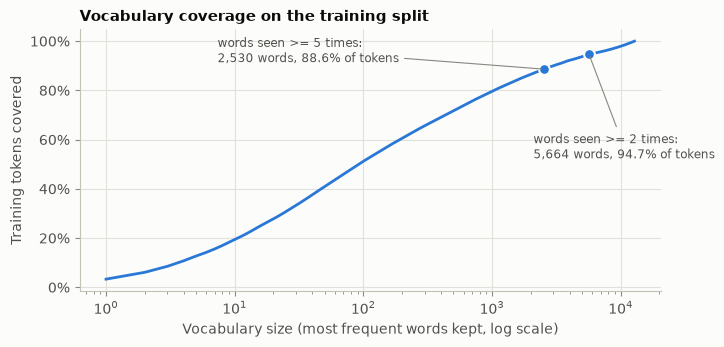

In [25]:
ranked = np.array(sorted(freq.values(), reverse=True))
coverage = np.cumsum(ranked) / total
fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.plot(np.arange(1, len(ranked) + 1), coverage, color=SERIES)
ax.set_xscale("log")
label_offsets = {5: (-235, 5), 2: (-40, -75)}
for min_count in [5, 2]:
    n_kept = int((ranked >= min_count).sum())
    ax.scatter([n_kept], [coverage[n_kept - 1]], s=60, color=SERIES, edgecolor=SURFACE, linewidth=1.5, zorder=3)
    ax.annotate(f"words seen >= {min_count} times:\n{n_kept:,} words, {coverage[n_kept - 1]:.1%} of tokens",
                (n_kept, coverage[n_kept - 1]), xytext=label_offsets[min_count], textcoords="offset points",
                fontsize=8.5, color=INK_2, arrowprops={"arrowstyle": "-", "color": MUTED, "linewidth": 0.8})
ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0))
ax.set_xlabel("Vocabulary size (most frequent words kept, log scale)")
ax.set_ylabel("Training tokens covered")
ax.set_title("Vocabulary coverage on the training split")
save_fig(fig, "eda_vocabulary_coverage")
plt.show()

The coverage curve shows why this trade-off is not very costly. It rises quickly at first, with the most frequent thousand words already covering around 80% of the text, and then flattens out so each extra word adds very little. As a result going from 2,530 words (seen at least 5 times) to 5,664 words (seen at least twice) only adds about 6 percentage points of coverage, which suggests that a vocabulary of a few thousand words should be enough for these models.

In [26]:
train_len = train_tokens.str.len()
pcts = np.percentile(train_len, [50, 90, 95, 99, 99.9, 100])
print("training tokens per tweet - 50/90/95/99/99.9/100th percentile:", pcts)
for max_len in [24, 28, 32, 40]:
    print(f"max_len={max_len}: {100 * (train_len <= max_len).mean():.2f}% of training tweets fit without truncation "
          f"({int((train_len > max_len).sum())} tweets truncated)")

training tokens per tweet - 50/90/95/99/99.9/100th percentile: [17. 24. 25. 28. 32. 48.]
max_len=24: 93.00% of training tweets fit without truncation (560 tweets truncated)
max_len=28: 99.26% of training tweets fit without truncation (59 tweets truncated)
max_len=32: 99.93% of training tweets fit without truncation (6 tweets truncated)
max_len=40: 99.99% of training tweets fit without truncation (1 tweets truncated)


For the sequence length `max_len = 32` keeps 99.93% of the training tweets complete and only cuts 6 of them, whereas a length of 28 would cut 59 tweets and 24 would cut 560. Going longer does not help much either since a length of 40 would only save 5 more tweets while adding extra padding to every tweet, so 32 seems to be the best balance between keeping the text complete and keeping the sequences short.

Based on these results these are my suggestions for the rest of the group, meant as a starting point for their experiments rather than as fixed rules:

- For the neural models start with a vocabulary of the words seen at least twice (about 5,700 tokens including one for unknown words) and `max_len = 32` and treat the vocabulary size as something worth testing, for example 2,500 against 5,700 against all words.
- Make the recurrent layer ignore the padding for example by using `Embedding(mask_zero=True)` so that the padding zeros added to short tweets are not treated as real input.
- For the TF-IDF baselines I will test keeping all words against keeping only words that appear in at least two tweets.

## 11. Choosing the Evaluation Metric

The official starter notebook treats `label` as a number, trains a regression model with `metrics=[rmse]` and says that RMSE "is the metric used in the competition" so we follow the same approach and use RMSE (root mean squared error) as our main metric. It also suits these labels well because they have a natural order from -1 to +1, which means that predicting 0.5 for a positive tweet is less wrong than predicting -1 and RMSE takes that distance into account. Because the errors are squared, RMSE also punishes big mistakes much more than small ones, which is appropriate here since confusing an anti-vaccine tweet with a pro-vaccine one is the most serious error a model can make.

Alongside RMSE we also report MAE (mean absolute error), which is simply the average distance between the prediction and the true label. MAE is easier to interpret and less affected by a few very large errors so looking at the two together tells us what kind of errors a model makes: if its RMSE is much higher than its MAE, most of its error comes from a small number of big mistakes rather than from many small ones. I still need to support this choice with literature in the literature review.

To keep the comparison consistent every model is scored in the same way on the same 1,999 validation tweets and saves its predictions in `results/<model>_validation_predictions.csv` with the columns `tweet_id`, `true_label` and `predicted_label`. An RMSE value means little without something to compare it to, however, so before training any model I calculated the score of a simple reference "model" that ignores the text completely and always predicts the average label of the training set.

In [27]:
train_mean = train_df[TARGET_COL].mean()
ref_pred = np.full(len(val_df), train_mean)
print(f"training-split mean label: {train_mean:.4f}")
print(f"reference (always predict the training mean): validation RMSE = {rmse(val_df[TARGET_COL], ref_pred):.4f}, "
      f"MAE = {mae(val_df[TARGET_COL], ref_pred):.4f}")

training-split mean label: 0.3013
reference (always predict the training mean): validation RMSE = 0.6459, MAE = 0.5656


Always predicting 0.301 gives a validation RMSE of 0.646 and an MAE of 0.566. Since this is the score of a model that never reads the tweets it sets the minimum that any real model has to beat clearly before we can say it has learned something useful from the text.

## Summary of Part 1 So Far

Taken together the analysis gives a fairly clear picture of what the models will face. The labels are imbalanced with only 10.4% negative tweets and this smallest class also has the weakest labels since all 239 tweets with 1/3 agreement are labelled -1. The same annotation problem shows up in the duplicates because about 6.6% of the tweets are near-duplicates and some of their copies carry different labels, which means part of the error cannot be removed by any model. The tweets themselves are short (median 17 tokens) but several of their social media features, such as mentions, links, "…", question marks and certain hashtags, appear at different rates in different labels, which is why the cleaning keeps them instead of removing them. Finally negation is common in both positive and negative tweets, some topic words are strongly linked to one label (autism) and some words have more than one meaning (MMR), so in many tweets the sentiment depends on word order and context rather than on single words, which is exactly what the sequential models are supposed to handle better.

The table below summarises what I am handing over to the rest of the group.

| Item | Decision |
|---|---|
| Data | `Train.csv`, 10,000 labelled tweets after fixing one broken record |
| Input and target | `safe_text` is used to predict `label` (-1, 0 or +1), treated as regression |
| Not used as input | `agreement` because a new tweet would not have it |
| Text cleaning | `prepare_text` / `prepare_series` from `src/preprocess.py`, default settings |
| Split | `splits/train_ids.csv` (8,001) and `splits/validation_ids.csv` (1,999), grouped by duplicate text, stratified by label and agreement, seed 42 |
| Fitting rule | tokenizers, vocabularies and TF-IDF are fitted on the training split only |
| Metric | RMSE (main) and MAE on the validation split; the reference RMSE to beat is 0.646 |
| Suggested settings for the neural models | vocabulary of words seen at least twice (about 5,700), `max_len = 32`, masking the padding |
| What each model saves | `results/<model>_validation_predictions.csv` (tweet_id, true_label, predicted_label) and one row per experiment in `results/experiment_results.csv` using `log_experiment` from `src/evaluate.py` |

These findings also lead to a few expectations that we will check in the experiments and the error analysis. I expect the models to make their biggest errors on negative tweets partly because this class is small and partly because some of its labels are weak. If word order really matters the models that read the tweet as a sequence should do better than the baselines on tweets that contain negation, although because the tweets are so short, LSTM and GRU may not be much better than the Simple RNN since their main advantage is remembering information over long sequences. Topic words like "autism" and ambiguous words like "MMR" may also lead some models into shortcut mistakes, which would show up as large errors on tweets that use these words in an unexpected way.

The next step is the literature review to confirm our five models, after which the Ridge and SVR baselines will be added to this notebook.